# Bài toán Kẻ mạo danh và dữ liệu theo cặp

Mỗi mẫu gồm hai ảnh chân dung `image_0` và `image_1`, có đúng một ảnh giả. Nhãn `fake_position = 0` nghĩa là ảnh bên trái giả; nhãn `fake_position = 1` nghĩa là ảnh bên phải giả.

Bài toán này là so sánh tương đối giữa hai ảnh trong cùng một cặp. Thay vì tìm một ngưỡng tĩnh để phân loại mọi ảnh đơn lẻ ngoài đời thực, mô hình cần so sánh hai bức ảnh để nhận biết bên nào có dấu hiệu can thiệp kỹ thuật số rõ hơn.

Dữ liệu có 1.000 cặp có nhãn. Ta áp dụng một giao thức học tập: chia cố định 800 cặp làm tập phát triển với 3 fold, và giữ riêng 200 cặp làm tập kiểm tra độc lập. Cách chia 800/200 và 3 fold này là thiết kế của bài học để phục vụ việc phát triển và so sánh có kiểm soát, không phải quy định bắt buộc của cuộc thi. Sau này, khi khóa toàn bộ quyết định thực nghiệm, bước huấn luyện lại trên toàn bộ 1.000 cặp sẽ gộp luôn 200 cặp này vào dữ liệu học; khi đó 200 cặp không còn là tập kiểm tra độc lập nữa.

Notebook này kiểm tra dữ liệu, định dạng mã `pair_id`, kiểm kê tệp ảnh, minh họa nhiều cặp ảnh mẫu và giải thích thước đo Macro-F1.

In [1]:
from pathlib import Path
import os
import sys

def find_task_root():
    explicit = os.environ.get('KMD_PROJECT_ROOT')
    if explicit:
        root = Path(explicit).expanduser().resolve()
        if (root / 'src/kmd').is_dir():
            return root
        raise FileNotFoundError('KMD_PROJECT_ROOT phải trỏ đến thư mục KeMaoDanh chứa src/kmd.')
    cwd = Path.cwd().resolve()
    for cand in [cwd, *cwd.parents]:
        if (cand / 'src/kmd').is_dir() and (cand / 'configs').is_dir():
            return cand.resolve()
        if (cand / 'KeMaoDanh/src/kmd').is_dir() and (cand / 'KeMaoDanh/configs').is_dir():
            return (cand / 'KeMaoDanh').resolve()
    raise FileNotFoundError("Không tìm thấy thư mục gốc KeMaoDanh chứa 'src/kmd' và 'configs'.")

TASK_ROOT = find_task_root()
if str(TASK_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(TASK_ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from kmd.core import PACKAGE, read_csv, split_fold, metric
from kmd.pipeline import prepare_development, inventory
from kmd.teaching import resolve_data_roots, show_pair_images

KMD_SMOKE = os.environ.get('KMD_SMOKE', '0') == '1'
KMD_RUN_ID = os.environ.get('KMD_RUN_ID', 'reasoning_pilot')
RUN_ID = f"{KMD_RUN_ID}_smoke" if (KMD_SMOKE and not KMD_RUN_ID.endswith('_smoke')) else KMD_RUN_ID

data_root, test_root = resolve_data_roots(TASK_ROOT)
if not data_root.is_dir() or not (data_root / 'pairs.csv').is_file():
    raise FileNotFoundError(
        f"Không tìm thấy thư mục dữ liệu huấn luyện tại '{data_root}'. "
        "Vui lòng thiết lập biến môi trường DATA_ROOT trỏ đến thư mục chứa 'pairs.csv' và 'images/'."
    )

dev_frame = prepare_development(data_root)
print(f"Thư mục dự án: {TASK_ROOT}")
print(f"Phiên làm việc: {RUN_ID} (smoke={KMD_SMOKE})")
print(f"Thư mục dữ liệu: {data_root}")
print(f"Tổng số cặp trong tập phát triển: {len(dev_frame)}")

Thư mục dự án: /home/purin1410-desktop/kmd_full_v5_20260920/repo/KeMaoDanh
Phiên làm việc: lesson_full_v5_20260920 (smoke=False)
Thư mục dữ liệu: /home/purin1410-desktop/kmd_revision_v3_20260920/input/extracted_final/data/train
Tổng số cặp trong tập phát triển: 800


## 1. Định dạng chuỗi của pair_id và bảng manifest

Giữ `pair_id` dưới dạng chuỗi; mã có thể chứa các số 0 ở đầu (ví dụ `00001`, `00578`).

Nếu đọc dữ liệu tự động mà không chỉ định kiểu, các số 0 ở đầu dễ bị mất do bị ép thành số nguyên (thành `1`, `578`), dẫn đến lỗi khi ghép nối kết quả dự đoán. Hàm `read_csv` trong `kmd.core` luôn đặt kiểu dữ liệu của `pair_id` là chuỗi ký tự (`str`).

Bảng dữ liệu phát triển chứa các cột: `pair_id`, `image_0`, `image_1`, `fake_position` và `inner_fold`.

In [2]:
print(f"Kiểu dữ liệu của cột pair_id: {dev_frame.pair_id.dtype}")
print(f"Số lượng cặp phát triển: {len(dev_frame)}")
print(f"Mã định danh duy nhất: {dev_frame.pair_id.nunique()} / {len(dev_frame)}")
print(f"Các giá trị nhãn xuất hiện: {sorted(dev_frame.fake_position.unique())}")

print("\nNăm mẫu đầu tiên trong tập phát triển:")
print(dev_frame[['pair_id', 'image_0', 'image_1', 'fake_position', 'inner_fold']].head(5).to_string(index=False))

Kiểu dữ liệu của cột pair_id: object
Số lượng cặp phát triển: 800
Mã định danh duy nhất: 800 / 800
Các giá trị nhãn xuất hiện: [np.int64(0), np.int64(1)]

Năm mẫu đầu tiên trong tập phát triển:
pair_id          image_0          image_1  fake_position  inner_fold
  00001 images/00295.jpg images/01131.jpg              1           2
  00004 images/01000.jpg images/00449.jpg              1           2
  00005 images/01117.jpg images/01089.jpg              1           0
  00006 images/01265.jpg images/01659.jpg              0           2
  00007 images/00663.jpg images/00036.jpg              0           2


## 2. Quan sát nhiều cặp ảnh trên tập huấn luyện

Nhìn bằng mắt có thể giúp ta nhận ra một số điểm nghi vấn ở viền tóc, ánh sáng mắt hoặc vùng nền. Tuy nhiên, sự khác biệt quan sát được trên một cặp chưa chắc đã lặp lại ở cặp khác.

Để tuân thủ nguyên tắc không xem trước dữ liệu kiểm định, ta chỉ chọn mẫu từ phần train của Fold 0 (gồm các cặp thuộc Fold 1 và Fold 2). Dưới đây là ba cặp đầu tiên theo thứ tự `pair_id` để làm quen với cách đọc cặp. Ba mẫu này không đại diện toàn bộ dữ liệu.

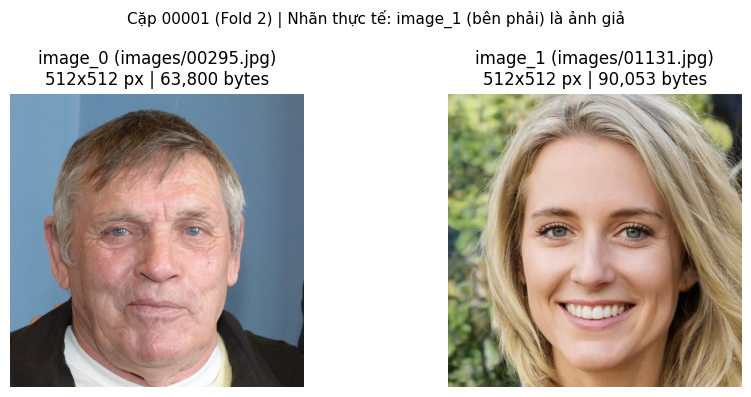

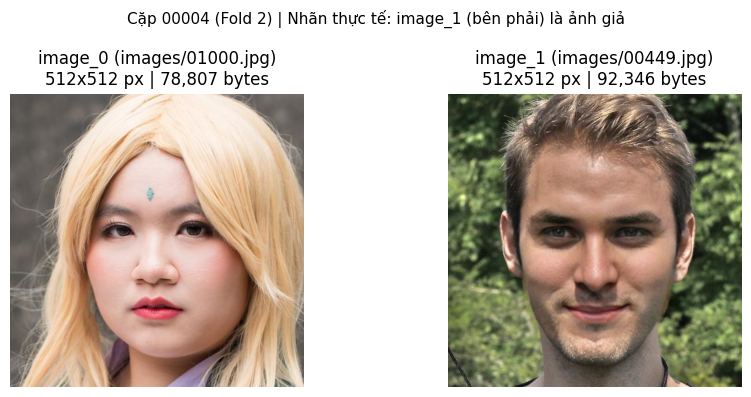

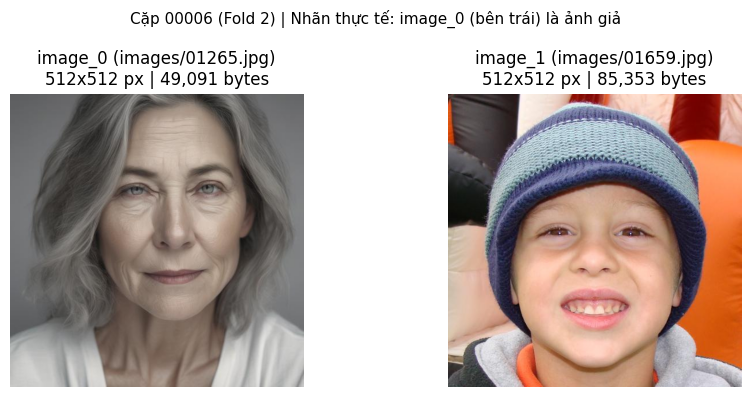

In [3]:
tr_fold0, va_fold0 = split_fold(dev_frame, fold=0)
sample_pairs = tr_fold0.sort_values('pair_id').head(3)

for idx, row in sample_pairs.iterrows():
    pos_text = "image_0 (bên trái)" if row.fake_position == 0 else "image_1 (bên phải)"
    title = f"Cặp {row.pair_id} (Fold {row.inner_fold}) | Nhãn thực tế: {pos_text} là ảnh giả"
    show_pair_images(row, data_root, title=title)

## 3. Kiểm kê tệp ảnh và kiểm tra rò rỉ dữ liệu

Trước khi trích xuất đặc trưng, ta kiểm kê toàn bộ ảnh: kích thước chiều cao và chiều rộng, dung lượng byte và mã băm SHA256 của từng tệp.

Hàm `inventory` trong `kmd.pipeline` kiểm tra định dạng và xác minh các ảnh đạt độ phân giải tối thiểu 224 pixel. Hàm này cũng đối chiếu mã SHA256 giữa các fold để bảo đảm không có tệp ảnh nào có nội dung byte trùng lặp xuất hiện ở cả hai phía của một phân chia huấn luyện và kiểm định.

In [4]:
inv_table = inventory(dev_frame, data_root)

print(f"Tổng số tệp ảnh duy nhất trong 800 cặp: {len(inv_table)}")
print(f"Các kích thước ảnh xuất hiện (cao, rộng): {set(zip(inv_table.height, inv_table.width))}")
print(f"Dung lượng tệp nhỏ nhất: {inv_table.bytes.min():,} bytes")
print(f"Dung lượng tệp trung vị:  {int(inv_table.bytes.median()):,} bytes")
print(f"Dung lượng tệp lớn nhất:  {inv_table.bytes.max():,} bytes")

print("\nBốn dòng đầu của bảng kiểm kê:")
print(inv_table.head(4).to_string(index=False))

Tổng số tệp ảnh duy nhất trong 800 cặp: 1600
Các kích thước ảnh xuất hiện (cao, rộng): {(512, 512)}
Dung lượng tệp nhỏ nhất: 32,609 bytes
Dung lượng tệp trung vị:  71,017 bytes
Dung lượng tệp lớn nhất:  147,769 bytes

Bốn dòng đầu của bảng kiểm kê:
         relpath  width  height  bytes                                                           sha256
images/00001.jpg    512     512  75409 a0b869789019c82a6de91a7eb1865be3f169bbef05f4667340f7d085d119a1d7
images/00003.jpg    512     512  88756 c0e4bf875ab07fbf33142e0b64d1c36ce2fc08bd36c3f13c039e84a5d6fd89ca
images/00004.jpg    512     512  98652 23d0452eed7db060045b0012ad66f3193bd93e6ce8bc79ff910f07bf4b57c3ad
images/00006.jpg    512     512  72919 226da519bf1b7d88c9612acee80ae0f0039bbae33c1f60816ee4b890b639c37e


## 4. Giao thức 800/200 và kiểm định chéo 3 fold

Tập dữ liệu có 1.000 cặp ảnh có nhãn. Ta sử dụng tệp `configs/development_split.csv` để ấn định 800 cặp phát triển và 200 cặp giữ lại.

Việc chia 800/200 cùng cấu trúc 3 fold này là một giao thức học tập có chủ đích:
- 800 cặp phát triển được chia thành ba phần cân bằng (khoảng 267 cặp mỗi fold). Ở mỗi fold, mô hình học từ hai phần và dự đoán trên phần còn lại. Khi ghép dự đoán của cả ba fold, ta có bảng kết quả Out-Of-Fold (OOF) trên toàn bộ 800 cặp để so sánh các ý tưởng.
- 200 cặp còn lại được giữ riêng, không tham gia vào quá trình khám phá hay chọn mô hình trong các bài học này.
- Khi đánh giá trên tập thi đấu thực tế, chiến lược huấn luyện lại (refit) trên toàn bộ 1.000 cặp sẽ đưa 200 cặp này vào làm dữ liệu học. Khi đã refit, 200 cặp đó trở thành dữ liệu huấn luyện, không còn là tập kiểm tra độc lập.

In [5]:
fold_summary = dev_frame.groupby('inner_fold').agg(
    so_cap=('pair_id', 'count'),
    so_nhan_0=('fake_position', lambda s: (s == 0).sum()),
    so_nhan_1=('fake_position', lambda s: (s == 1).sum()),
    ty_le_nhan_1=('fake_position', 'mean')
).reset_index()

print("Phân bố số lượng và tỷ lệ nhãn theo từng fold kiểm định:")
print(fold_summary.to_string(index=False))

Phân bố số lượng và tỷ lệ nhãn theo từng fold kiểm định:
 inner_fold  so_cap  so_nhan_0  so_nhan_1  ty_le_nhan_1
          0     267        133        134      0.501873
          1     267        134        133      0.498127
          2     266        133        133      0.500000


## 5. Thước đo đánh giá Macro-F1

Thước đo chính của bài toán là Macro-F1:

$$F1_k = \frac{2 \cdot TP_k}{2 \cdot TP_k + FP_k + FN_k}, \qquad \text{Macro-F1} = \frac{F1_0 + F1_1}{2}$$

Với mỗi vị trí $k \in \{0, 1\}$, $TP_k$ là số cặp đoán đúng vị trí $k$, $FP_k$ là số cặp bị đoán nhầm sang vị trí $k$, và $FN_k$ là số cặp có vị trí thực tế là $k$ nhưng bị bỏ sót.

Độ chính xác (Accuracy) chỉ tính tỷ lệ dự đoán đúng trên tổng số cặp. Nếu dữ liệu lệch và mô hình luôn đoán một phía, Accuracy có thể vẫn cao nhưng F1 của phía kia bằng 0. Macro-F1 lấy trung bình cộng F1 của cả hai phía, đòi hỏi mô hình phải nhận diện tốt cả hai vị trí ảnh giả.

Ví dụ dưới đây minh họa sự khác biệt giữa hai thước đo trên một tập mẫu gồm 10 cặp.

In [6]:
# Tập ví dụ gồm 8 mẫu nhãn 0 và 2 mẫu nhãn 1
y_demo = np.array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1])

# Mô hình A: Thiên lệch, luôn dự đoán vị trí 0 với xác suất cao
p_demo_a = np.full(10, 0.1)

# Mô hình B: Có khả năng nhận biết cả hai vị trí
p_demo_b = np.array([0.15, 0.20, 0.10, 0.35, 0.25, 0.10, 0.40, 0.75, 0.85, 0.30])

m_a = metric(y_demo, p_demo_a)
m_b = metric(y_demo, p_demo_b)

df_metrics = pd.DataFrame([
    {'Mô hình': 'Mô hình A (luôn đoán vị trí 0)', 'accuracy': m_a['accuracy'], 'macro_f1': m_a['macro_f1'], 'errors': m_a['errors']},
    {'Mô hình': 'Mô hình B (phân biệt hai phía)', 'accuracy': m_b['accuracy'], 'macro_f1': m_b['macro_f1'], 'errors': m_b['errors']},
])
print(df_metrics[['Mô hình', 'accuracy', 'macro_f1', 'errors']].to_string(index=False))

                       Mô hình  accuracy  macro_f1  errors
Mô hình A (luôn đoán vị trí 0)       0.8  0.444444       2
Mô hình B (phân biệt hai phía)       0.8  0.687500       2


## 6. Từ định nghĩa bài toán sang tìm kiếm tín hiệu

Mục tiêu dự đoán là vị trí ảnh giả trong từng cặp ảnh chân dung. Mã `pair_id` được giữ nguyên dạng chuỗi để bảo đảm tính toàn vẹn khi nộp bài. Giao thức 800/200 và 3 fold OOF tạo nền tảng để so sánh các cách tiếp cận một cách nhất quán.

Một dấu hiệu bạn nhận ra bằng mắt có lặp lại trên nhiều cặp không? Ta chuyển dấu hiệu đó thành đại lượng đo được, rồi kiểm tra phân bố và các trường hợp ngoại lệ.

[Bài 01](01_eda_and_baseline.ipynb) bắt đầu hành trình khám phá dữ liệu (EDA): đo dung lượng tệp, phân bố màu sắc, chi tiết phần dư và thống kê vùng trung tâm so với vùng biên, sau đó đánh giá một quy tắc dự đoán cơ sở dựa trên dung lượng tệp.